In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Algerian_forest_fire_clean_dataset.csv')

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
# delete day month year
cols_drop=['day','month','year']
df.drop(columns=cols_drop,inplace=True,axis=1)

In [10]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [12]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [13]:
## encoding of classes
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [15]:
# Independent and dependent feature
X=df.drop('FWI',axis=1)
y=df['FWI']

In [18]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [19]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

# Train test split

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [21]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((182, 11), (61, 11), (182,), (61,))

# Feature selection based on correlation

<Axes: >

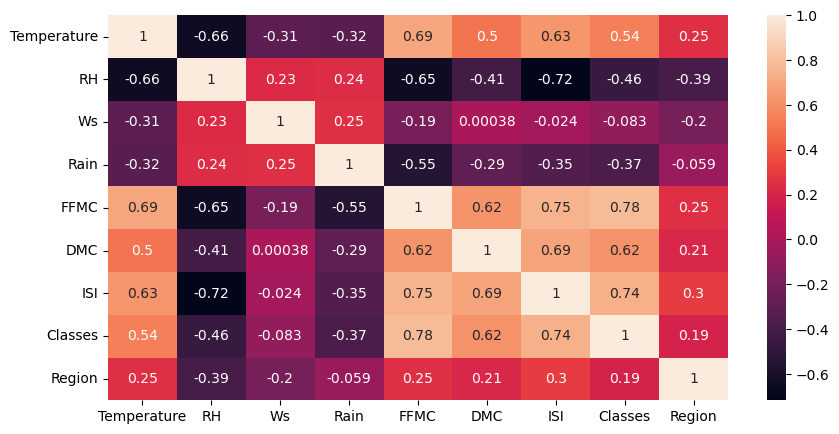

In [60]:
plt.figure(figsize=(10,5))
sns.heatmap(X_train.corr(),annot=True)

In [31]:
def correlation(dataset,threshold):
    col_corr=set()
    corr_metrix=dataset.corr()
    for i in range(len(corr_metrix.columns)):
        for j in range(i):
            if abs(corr_metrix.iloc[i,j]) > threshold:
                colname=corr_metrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [39]:
# threshold feature expertise
corr_features=correlation(X_train,0.85)

In [40]:
corr_features # these are the highly correlated feature so delete them 

set()

In [37]:
## drop feature having more than corr 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [42]:
X_train.shape,X_test.shape

((182, 9), (61, 9))

# Feature scaling or standardization

In [43]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Box plots to understand outliers before scaled and after scaled

Text(0.5, 1.0, 'X_train after scaled')

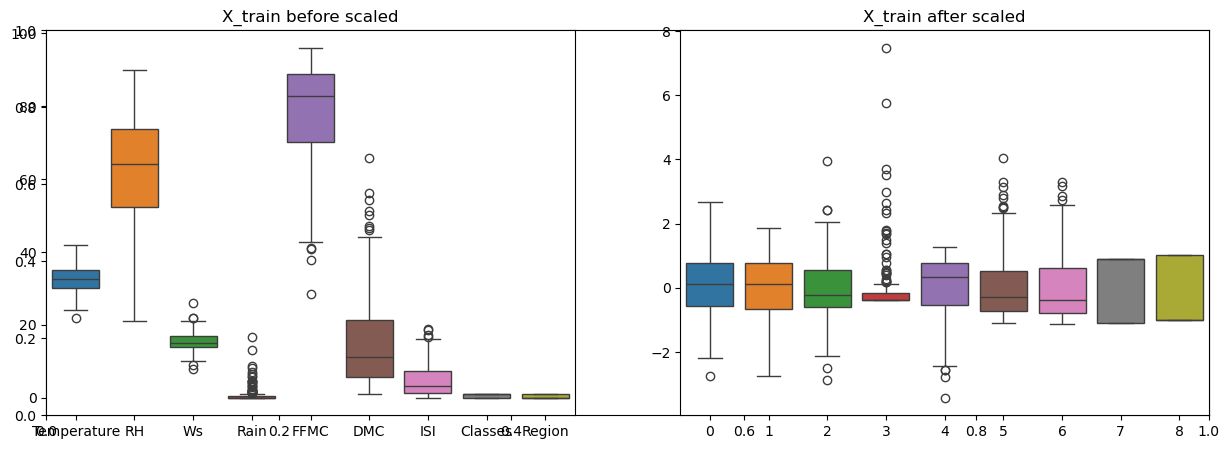

In [52]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title("X_train before scaled")

plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.title("X_train after scaled")

# Linear Regression model

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

Lg=LinearRegression()
Lg.fit(X_train_scaled,y_train)
y_pred=Lg.predict(X_test_scaled)

print("Mean absolute error is ",mean_absolute_error(y_test,y_pred))
print("r2 score is ",r2_score(y_test,y_pred))

Mean squared error is  0.5468236465249973
r2 score is  0.9847657384266952


# Lasso Regression

In [56]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

LS=Lasso()
LS.fit(X_train_scaled,y_train)
y_pred=LS.predict(X_test_scaled)

print("Mean absolute error is ",mean_absolute_error(y_test,y_pred))
print("r2 score is ",r2_score(y_test,y_pred))

Mean absolute error is  1.1331759949144087
r2 score is  0.9492020263112388


# Ridge regression model

In [57]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

Rd=Ridge()
Rd.fit(X_train_scaled,y_train)
y_pred=Rd.predict(X_test_scaled)

print("Mean absolute error is ",mean_absolute_error(y_test,y_pred))
print("r2 score is ",r2_score(y_test,y_pred))

Mean absolute error is  0.5642305340105692
r2 score is  0.9842993364555513


# Elastic net Regression

In [58]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

EN=ElasticNet()
EN.fit(X_train_scaled,y_train)
y_pred=EN.predict(X_test_scaled)

print("Mean absolute error is ",mean_absolute_error(y_test,y_pred))
print("r2 score is ",r2_score(y_test,y_pred))

Mean absolute error is  1.8822353634896
r2 score is  0.8753460589519703


# Pickle( Lasso model )

In [62]:
import pickle
pickle.dump(LS,open('forest_fire_Ml_Model_pickle_file','wb'))

# Pickle( Ridge Model )

In [67]:
import pickle
pickle.dump(Rd,open('forest_fire_Ml_Model_ridge_pickle_file','wb'))
pickle.dump(scaler,open('forest_fire_scaler_pickle_file','wb'))